# N3 — LangGraph com LLMs

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Introduzimos como usar LLMs dentro do LangGraph. O foco não é apenas chamar um modelo de linguagem, mas a orquestrar chamadas de LLM dentro de grafos com estado compartilhado, decisões condicionais e controle explícito do fluxo de execução.

## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- concluído ou entendido os conceitos da Aula 01;
- noções básicas de LLMs;
- familiaridade básica com LangChain;
- noções de mensagens conversacionais, como mensagens de usuário, sistema e assistente.

## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Criar um chatbot mínimo com LangGraph.
2. Entender por que `messages` é o estado natural de aplicações conversacionais.
3. Usar `add_messages` explicitamente como reducer.
4. Adicionar comportamento ao nó com prompt de sistema.
5. Observar a execução do grafo com `stream`.
6. Usar um LLM como classificador de intenção.
7. Criar nós especializados por intenção.
8. Fazer roteamento condicional com base na saída do LLM.
9. Criar um ciclo simples de geração, avaliação e revisão com LLM.

## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. Um chatbot mínimo.
2. Um grafo com estado baseado em mensagens.
3. Um nó com prompt de sistema.
4. Execução observável com `stream`.
5. Um classificador de intenção usando LLM.
6. Um fluxo com roteamento condicional.
7. Nós especializados para diferentes intenções.
8. Um ciclo de geração, avaliação e revisão.


---

## 0.4 Preparação do ambiente

Este notebook assume que você já tem o ambiente configurado para usar LangChain e um provedor de LLM.

Para tornar a aula acessível a todo mundo, vamos apresentar formas de obter um modelo de linguagem, e você escolhe qual usar:

| Opção | O que é | Precisa de chave? | Precisa de internet? |
|---|---|---|---|
| **A. Ollama** | Roda um modelo pequeno *localmente*, na sua máquina | Não | Não (depois de baixado) |
| **B. Provedor via API** | Usa um modelo hospedado na nuvem, através de uma chave de API | Sim | Sim |

A Opção B tem vários provedores possíveis — Google Gemini, OpenAI, Groq, Anthropic, Mistral, entre outros. O processo de configuração é sempre parecido (gerar uma chave no site do provedor, guardá-la como variável de ambiente, instalar o pacote correspondente), só muda o site, o nome da variável e, em alguns casos, se o uso é realmente gratuito.

Neste notebook, configuramos **dois exemplos de provedor via API** — Google Gemini e OpenAI — para deixar clara essa diferença na prática: o Gemini tem uma camada gratuita genuína (sem cartão de crédito), enquanto a OpenAI hoje exige créditos pré-pagos para a maioria dos modelos. A mesma lógica se aplica caso você prefira usar outro provedor, como o Groq — mostramos essa equivalência mais abaixo.

Se você já tem o Ollama instalado, pode simplesmente seguir com a Opção A. Se preferir não instalar nada localmente (ou estiver em um ambiente como o Google Colab), a Opção B é mais simples de começar.

Vamos configurar as opções abaixo, passo a passo. No final, você escolhe qual variável `llm` usar no restante da aula — o resto do notebook não muda.

Se estiver em um ambiente novo, descomente a célula abaixo para instalar as dependências.

In [65]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langgraph langchain langchain-ollama pydantic

# Cada provedor via API tem seu próprio pacote de integração. Instale apenas o(s) que for usar.
# Neste notebook usamos Gemini e OpenAI como exemplos, mas o processo é o mesmo para outros provedores:
#python -m pip install -U "langchain[google-genai]" langchain-google-genai langchain-core   # Google Gemini (exemplo 1 neste notebook)
%pip install -U langchain-google-genai 
%pip install -U langchain-openai         # OpenAI (exemplo 2 neste notebook)
# %pip install -U langchain-groq           # Groq (outro provedor com camada gratuita)
# %pip install -U langchain-anthropic      # Anthropic

# Utilitário para ler a chave de API de variáveis de ambiente / arquivo .env
%pip install -U python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#'

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [9]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages

from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Sequence, Literal

from rich import print
from rich.markdown import Markdown

Importamos os elementos básicos que serão usados.

- `init_chat_model`: usado para inicializar o modelo de chat.
- `HumanMessage`, `SystemMessage` e `BaseMessage`: usados para representar mensagens conversacionais.
- `StateGraph`, `START` e `END`: usados para construir o grafo e definir seus pontos inicial e final.
- `add_messages`: reducer usado para acumular mensagens no estado.
- `BaseModel` e `Field`: usados para definir saídas estruturadas com Pydantic.
- `TypedDict`, `Annotated`, `Sequence` e `Literal`: usados para tipar o estado, reducers, sequências de mensagens e rotas condicionais.

---

## 0.5 Escolhendo um provedor de LLM

`init_chat_model` é uma função genérica do LangChain: ela recebe uma string no formato `"provedor:nome-do-modelo"` e devolve um objeto de chat pronto para usar, independente de qual provedor está por trás.

Isso significa que, depois de instanciado, o restante do notebook (`llm.invoke(...)`, `llm.with_structured_output(...)`, etc.) funciona **da mesma forma**, não importa se o modelo está rodando localmente ou na nuvem, e não importa qual provedor de API você escolheu.

Existem duas famílias de opção:

- **Local (Ollama)**: não precisa de chave, mas exige instalar o programa e baixar o modelo.
- **Via API (nuvem)**: precisa de uma chave de API, mas não exige processamento local. Existem vários provedores possíveis — Google Gemini, OpenAI, Groq, Anthropic, Mistral, e outros. Cada um tem seu próprio pacote de integração e seu próprio site para gerar a chave, mas o padrão de uso é sempre o mesmo: `init_chat_model("provedor:modelo")` (ou a classe específica do provedor) + a chave disponível como variável de ambiente.

A seguier, configuramos o Ollama e, como exemplos de provedor via API, o **Google Gemini** e a **OpenAI**. Você pode rodar todas as células, ou apenas a(s) que for usar — a escolha final acontece em [0.5.4](#054-escolhendo-qual-llm-usar).

### 0.5.1 Opção A — Ollama (modelo local, sem chave)

[Ollama](https://ollama.com) é um programa que baixa e roda modelos de linguagem *na sua própria máquina*. Como o modelo roda localmente, não é preciso nenhuma chave de API — mas você precisa ter memória/processamento suficiente e o programa instalado.

**Passo a passo:**

1. Baixe e instale o Ollama em **https://ollama.com/download** (disponível para Windows, macOS e Linux).
2. Abra um terminal e baixe um modelo, por exemplo:
   ```bash
   ollama pull llama3.2:3b
   ```
3. Pronto — nenhuma chave é necessária. O LangChain se conecta ao Ollama em `http://localhost:11434` por padrão.

> Se você trocar o modelo baixado no passo 2, ajuste o nome usado na célula abaixo (`"ollama:llama3.2:3b"`) para corresponder.

In [3]:
# Instancia o modelo local via Ollama.
# Ajuste o nome do modelo conforme o que você baixou com "ollama pull".
llm_ollama = init_chat_model("ollama:llama3.2:3b", temperature=0)

### 0.5.2 Opção B — Provedor via API (exemplo: Google Gemini)

Vamos usar o **Google Gemini** como exemplo de provedor via API, porque a chave é gratuita e fácil de gerar. O processo é praticamente idêntico para outros provedores — muda apenas o site onde se gera a chave, o nome da variável de ambiente e o pacote instalado. Por exemplo, com o **Groq** (outro provedor com camada gratuita), o fluxo seria o mesmo: gerar a chave em **https://console.groq.com/keys**, guardá-la como `GROQ_API_KEY`, instalar `langchain-groq`, e instanciar com `init_chat_model("groq:llama-3.3-70b-versatile")`. Logo abaixo, repetimos esse mesmo processo com a OpenAI, para você comparar as duas experiências na prática.

O Google oferece acesso gratuito (com limites de uso) aos modelos Gemini através do **Google AI Studio**. Diferente do Ollama, o modelo roda nos servidores do Google, então é preciso enviar uma chave de API a cada chamada — por isso ela precisa estar configurada no seu ambiente.

**Passo a passo para gerar a chave gratuita do Gemini:**

1. Acesse **https://aistudio.google.com/apikey** e faça login com uma conta Google.
2. Clique em **"Create API key"** (ou "Criar chave de API").
3. Escolha um projeto (ou deixe o Google criar um para você) e confirme.
4. Copie a chave gerada — ela é uma string longa, algo como `AIzaSy...`.

**Por que não colar a chave direto no código?**

Se você colar a chave como texto (`google_api_key="AIzaSy..."`) e depois compartilhar o notebook (por exemplo, no GitHub), qualquer pessoa poderá usar sua chave e gastar sua cota gratuita. Por isso, o padrão é guardar a chave em uma **variável de ambiente**, fora do código-fonte — essa prática vale para qualquer provedor via API, não só o Gemini. Existem três formas comuns de fazer isso — escolha a que preferir:

**Forma 1 — digitar a chave na hora (mais simples para testar agora)**

A célula de código abaixo pergunta a chave de forma oculta (como uma senha) e a guarda apenas na memória desta sessão, sem salvar em nenhum arquivo.

**Forma 2 — arquivo `.env` (recomendado para projetos)**

Crie um arquivo chamado `.env` na mesma pasta do notebook, com o seguinte conteúdo:

```
GOOGLE_API_KEY=sua_chave_aqui
```

Esse arquivo **não deve ser versionado** (adicione `.env` ao seu `.gitignore`). O `load_dotenv()`, importado anteriormente, lê esse arquivo automaticamente e disponibiliza a chave como variável de ambiente. Se você usasse outro provedor, o nome da variável mudaria (ex: `GROQ_API_KEY`, `OPENAI_API_KEY`), mas o arquivo `.env` funcionaria do mesmo jeito.

**Forma 3 — variável de ambiente do sistema operacional**

Antes de abrir o notebook, no terminal:

```bash
# Linux / macOS
export GOOGLE_API_KEY="sua_chave_aqui"

# Windows (PowerShell)
$env:GOOGLE_API_KEY="sua_chave_aqui"
```

A célula abaixo cobre as três formas: primeiro tenta carregar de um `.env` (Forma 2/3); se a chave ainda não estiver definida, pede que você digite (Forma 1).

In [20]:
# Utilitários para configurar a chave de API com segurança
import os
import getpass
from dotenv import load_dotenv

In [60]:
# Tenta carregar variáveis de um arquivo .env, se existir (Forma 2).
load_dotenv()

# Se a chave ainda não estiver disponível como variável de ambiente (Forma 3),
# pede que você digite manualmente, sem exibir o texto na tela (Forma 1).
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Cole aqui sua chave da API do Google AI Studio: ")

print("Chave GOOGLE_API_KEY configurada com sucesso." if "GOOGLE_API_KEY" in os.environ else "Chave não encontrada.")

Chave GOOGLE_API_KEY configurada com sucesso.

In [69]:
# Instancia o modelo Gemini via API — usado aqui apenas como EXEMPLO de provedor via API.
# "gemini-2.0-flash" tem uma camada gratuita generosa, ideal para estudar e prototipar.
# Se você tivesse escolhido outro provedor (ex: Groq), a linha seria parecida, trocando
# apenas o prefixo e o nome do modelo, ex: init_chat_model("groq:llama-3.3-70b-versatile", temperature=0)

from langchain_google_genai import ChatGoogleGenerativeAI

#llm_gemini = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
llm_gemini = init_chat_model("gemini-2.5-flash", temperature=0)

C:\Users\DELL\AppData\Local\Temp\ipykernel_54748\1982575650.py:9: DeprecationWarning: Inferred `model_provider='google_vertexai'` from 'gemini-2.5-flash'. This default will change to 'google_genai' in the next major release.To keep current behavior, pass `model_provider='google_vertexai'` (or use the prefix form, e.g. 'google_vertexai:gemini-2.5-flash'); for AI Studio / Gemini API, use 'google_genai' instead.
  llm_gemini = init_chat_model("gemini-2.5-flash", temperature=0)


ImportError: Initializing ChatVertexAI requires the langchain-google-vertexai package. Please install it with `pip install langchain-google-vertexai`

### 0.5.3 Opção C — Provedor via API (segundo exemplo: OpenAI)

Vamos repetir o mesmo processo com a **OpenAI**, para você ver como ele se aplica a um provedor diferente. A mecânica é idêntica à do Gemini — gerar uma chave, guardá-la como variável de ambiente, instanciar o modelo — mas há uma diferença importante que vale a pena conhecer antes de começar.

**Atenção: a OpenAI, ao contrário do Gemini, não tem mais uma camada realmente gratuita.**

Até meados de 2025, novas contas na OpenAI recebiam alguns dólares em créditos gratuitos automaticamente. Isso não existe mais. Hoje, criar uma chave é gratuito, mas usá-la na maioria dos modelos (como o `gpt-4o-mini`) exige créditos pré-pagos (o valor mínimo costuma ser de US$ 5). Existe um nível gratuito bem limitado, restrito ao modelo `gpt-3.5-turbo` e a poucas requisições por minuto — insuficiente para a maior parte dos exemplos deste notebook.

Por isso, se o seu objetivo é rodar a aula inteira sem gastar nada, a combinação **Ollama** (local) ou **Gemini** (API gratuita) é a mais indicada. A seção da OpenAI aqui serve para você entender o processo e comparar as opções, caso já tenha ou queira usar créditos pagos.

**Passo a passo para gerar a chave:**

1. Acesse **https://platform.openai.com/api-keys** e faça login (ou crie uma conta).
2. Clique em **"Create new secret key"**.
3. Dê um nome para a chave (opcional) e confirme.
4. Copie a chave gerada imediatamente — ela começa com `sk-...` e só é exibida uma vez.
5. Se for usar modelos além do nível gratuito limitado, adicione créditos em **Settings → Billing**.

A mesma regra de segurança do Gemini vale aqui: **nunca cole a chave diretamente no código**, principalmente se for compartilhar o notebook. Use uma das mesmas três formas já vistas (digitar com `getpass`, arquivo `.env`, ou variável de ambiente do sistema) — a célula abaixo segue o mesmo padrão, agora para `OPENAI_API_KEY`.

**Se aparecer um erro de quota (`insufficient_quota` ou `RateLimitError 429`):**

Isso significa que a chave está correta, mas a conta não tem créditos disponíveis. As opções são: adicionar créditos na conta OpenAI, ou voltar a usar Ollama/Gemini trocando o `PROVEDOR` na célula de escolha final.

In [13]:
# Tenta carregar variáveis de um arquivo .env, se existir (Forma 2).
load_dotenv()

print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

Chave OPENAI_API_KEY configurada com sucesso.

In [22]:
# Instancia o modelo da OpenAI via API — segundo EXEMPLO de provedor via API.
# "gpt-4o-mini" é um dos modelos mais baratos da OpenAI, mas ainda assim exige créditos pré-pagos na conta.
from langchain_openai import ChatOpenAI
#llm_openai = ChatOpenAI("openai:gpt-4o-mini", temperature=0)
llm_openai = init_chat_model("openai:gpt-4o-mini", temperature=0)

### 0.5.4 Escolhendo qual LLM usar

Todo o restante do notebook usa a variável `llm`. Basta escolher, na célula abaixo, qual dos modelos instanciados acima você quer usar — o resto do código não precisa ser alterado.

In [23]:
# Troque entre "ollama", "gemini" e "openai" conforme o que você configurou acima.
PROVEDOR = "openai"

if PROVEDOR == "ollama":
    llm = llm_ollama
elif PROVEDOR == "gemini":
    llm = llm_gemini
elif PROVEDOR == "openai":
    llm = llm_openai
else:
    raise ValueError("PROVEDOR deve ser 'ollama', 'gemini' ou 'openai'.")

print(f"Usando provedor: {PROVEDOR}")

Usando provedor: openai

Vamos criar uma função auxiliar para exibir os grafos compilados, e também, uma função auxiliar para imprimir a última mensagem de uma execução


In [24]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display

def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

def print_last_message(result: dict) -> None:
    """Imprime o conteúdo da última mensagem de uma execução com estado de mensagens."""
    print(Markdown(result["messages"][-1].text))

---

# 1. Premissa da aula: o LLM não é o grafo

Em LangChain, frequentemente pensamos em composições como:

```text
prompt → model → parser
```

Em LangGraph, o modelo mental muda:

```text
estado → nó → atualização de estado → próxima decisão
```

O LLM pode aparecer em vários papéis:

- responder;
- classificar;
- avaliar;
- revisar;
- decidir;
- transformar dados.

Mas quem define a arquitetura da aplicação é o **grafo**.

Exemplo:

```text
START
  ↓
classificar_intencao_com_llm
  ↓
rotear
  ├── responder_conceito
  ├── gerar_codigo
  ├── criar_exercicio
  └── fallback
  ↓
END
```

Neste notebook, vamos construir exatamente esse tipo de fluxo.


---

# 2. Chatbot mínimo

O menor exemplo útil com LLM em LangGraph é um chatbot com um único nó.

Fluxo:

```text
START → chatbot → END
```

O ponto importante é:

> O LLM está dentro de um nó.  
> O grafo continua controlando o fluxo de execução.


In [25]:
class StateAgent(TypedDict):
    messages: str

In [26]:
def chatbot(state: StateAgent):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

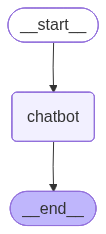

In [27]:
builder = StateGraph(StateAgent)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

chat_graph = builder.compile()
display_graph(chat_graph)

Agora executamos o grafo com uma mensagem do usuário.


In [29]:
try:
    result = chat_graph.invoke({
        "messages": [
            HumanMessage(content="Explique LangGraph em uma frase.")
        ]
    })

    print_last_message(result)

except Exception as e:
    error_text = str(e)
    if "insufficient_quota" in error_text or "RateLimitError" in error_text or "429" in error_text:
        print("Erro de quota/limite de uso do provedor configurado em PROVEDOR.")
        print("Opção 1: se PROVEDOR == 'openai', adicione créditos na conta OpenAI (platform.openai.com/settings/billing).")
        print("Opção 2: troque PROVEDOR para 'gemini' ou 'ollama' na célula de escolha do LLM e execute-a novamente.")
    else:
        raise

LangGraph é uma plataforma que combina processamento de linguagem natural e grafos para facilitar a análise e a    
visualização de dados textuais complexos.

## O que aconteceu?

O estado inicial foi:

```python
{
    "messages": [HumanMessage(content="...")]
}
```

O nó `chatbot` recebeu esse estado, chamou o LLM e retornou:

```python
{
    "messages": [AIMessage(content="...")]
}
```

Como estamos usando `MessagesState`, o LangGraph sabe que novas mensagens devem ser adicionadas ao histórico, e não simplesmente substituir toda a lista.


---

# 3. Por que `messages` precisa de reducer

Em aplicações conversacionais, o campo `messages` normalmente é acumulativo.

Exemplo:

```text
HumanMessage("Oi")
AIMessage("Olá!")
HumanMessage("Explique LangGraph")
AIMessage("LangGraph é...")
```

Se cada atualização substituísse a lista inteira, perderíamos o histórico.

Por isso, LangGraph usa reducers para definir como uma atualização deve ser combinada com o estado anterior.

Vamos sair do atalho `MessagesState` e declarar isso explicitamente.


In [31]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

Aqui, `add_messages` é o reducer associado ao campo `messages`.

Isso significa:

```text
messages_antigas + messages_novas → messages_atualizadas
```

Agora vamos recriar o chatbot usando esse estado explícito.


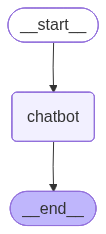

In [32]:
def chatbot_explicit(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(ChatState)

builder.add_node("chatbot", chatbot_explicit)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

explicit_chat_graph = builder.compile()
display_graph(explicit_chat_graph)

In [34]:
messages = [HumanMessage(content="O que é um reducer em LangGraph?")]
result = explicit_chat_graph.invoke({"messages": messages})

for message in result["messages"]:
    type_message = type(message).__name__
    print(Markdown('---'))
    print(f'[bold cyan]{type_message}:')
    print(Markdown(message.text))

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

HumanMessage:

O que é um reducer em LangGraph?

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

AIMessage:

Em LangGraph, um "reducer" é um conceito que se refere a uma função ou um mecanismo que transforma um conjunto de  
dados ou um estado em um resultado mais simples ou em um novo estado. O termo "reducer" é frequentemente associado 
a padrões de programação funcional e é comumente utilizado em bibliotecas de gerenciamento de estado, como Redux,  
no contexto de aplicações JavaScript.                                                                              

No contexto do LangGraph, um reducer pode ser utilizado para processar e manipular dados de forma eficiente,       
permitindo que você combine, filtre ou transforme informações de maneira a facilitar a construção de gráficos ou a 
execução de consultas. Ele pode ser parte de um fluxo de dados onde as entradas são processadas e o resultado final
é uma representação simplificada ou agregada dos dados.                                                            

Se você estiver trabalhando com LangGraph, o uso de reducers pode ajudar a manter seu código organizado e a lógica 
de manipulação de dados clara, permitindo que você se concentre na construção de suas aplicações de forma mais     
eficiente.

---

# 4. Adicionando comportamento com prompt de sistema

O estado guarda as mensagens da conversa, mas o nó pode enriquecer essas mensagens antes de chamar o LLM.

Isso é útil quando queremos controlar o papel do modelo.

Neste exemplo, vamos criar um tutor de LangGraph.


In [35]:
SYSTEM_PROMPT = """
Você é um tutor de LangGraph.

O aluno já conhece LLMs e LangChain.
Explique conceitos de forma objetiva, prática e técnica.
Use exemplos pequenos quando necessário.
Evite explicações genéricas sobre o que é um LLM.
"""


In [36]:
def tutor_node(state: ChatState):
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *state["messages"],
    ]

    response = llm.invoke(messages)

    return {"messages": [response]}


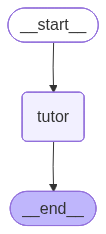

In [37]:
builder = StateGraph(ChatState)

builder.add_node("tutor", tutor_node)

builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

tutor_graph = builder.compile()
display_graph(tutor_graph)

In [38]:
messages =  [HumanMessage(content="Explique a diferença entre nó e aresta em LangGraph.")]
result = tutor_graph.invoke({"messages": messages})

print_last_message(result)

Em LangGraph, um nó (ou "node") representa uma entidade ou um ponto de dados, enquanto uma aresta (ou "edge")      
representa a relação ou a conexão entre esses nós.                                                                 

                                                        Nós                                                        

 • Definição: Um nó é uma unidade básica que contém informações ou dados. Pode ser um texto, um documento, uma     
   imagem, etc.                                                                                                    
 • Exemplo: Em um grafo que representa um conjunto de documentos, cada documento seria um nó.                      

                                                      Arestas                                                      

 • Definição: Uma aresta conecta dois nós e pode ter propriedades que descrevem a natureza da relação entre eles.  
 • Exemplo: Se você tem dois documentos (nós), uma aresta pode representar que um documento cita o outro.          

                                                  Exemplo Prático                                                  

Imagine um grafo simples com três nós: A, B e C.                                                                   

 • Nós:                                                                                                            
    • A: "Documento 1"                                                                                             
    • B: "Documento 2"                                                                                             
    • C: "Documento 3"                                                                                             
 • Arestas:                                                                                                        
    • Aresta de A para B: "Documento 1 cita Documento 2"                                                           
    • Aresta de B para C: "Documento 2 menciona Documento 3"                                                       

Neste exemplo, os nós representam os documentos e as arestas representam as relações de citação entre eles.        

                                                      Resumo                                                       

 • Nó: Entidade (ex: documento).                                                                                   
 • Aresta: Relação entre entidades (ex: citação).                                                                  

Essa estrutura permite modelar e navegar por dados complexos de forma eficiente.

---

# 5. Classificação de intenção com LLM

Agora vamos construir um fluxo mais interessante.

A ideia é:

```text
START
  ↓
classify_intent
  ↓
roteamento condicional
  ├── answer_concept
  ├── answer_code
  ├── create_exercise
  └── answer_fallback
  ↓
END
```

Aqui o LLM será usado como classificador, mas o roteamento será responsabilidade do LangGraph.

Isso é diferente de deixar o modelo "decidir tudo" dentro de um único prompt.


## 7.1 Estado do roteador

Vamos criar um estado com três campos principais:

- `pergunta`: entrada do usuário;
- `intencao`: categoria detectada;
- `resposta`: resposta final do sistema.


In [39]:
class RouterState(TypedDict):
    pergunta: str
    intencao: Literal["conceito", "codigo", "exercicio", "outro"]
    justificativa: str
    resposta: str

## 7.2 Saída estruturada para o classificador


Até aqui, o LLM retornava texto livre. Para respostas abertas, isso costuma ser suficiente. Porém, quando queremos usar a saída do modelo para controlar o fluxo do grafo, texto livre pode ser frágil.

Neste caso, o LLM será usado como **classificador de intenção**. A resposta dele será usada para decidir qual caminho o grafo deve seguir.

Por isso, vamos usar `with_structured_output`.

Esse método orienta o modelo a retornar uma saída seguindo um esquema definido previamente. Em vez de depender de uma string como `"conceito"` ou `"codigo"` solta no texto, definimos explicitamente quais campos esperamos receber.

Para isso, vamos criar um modelo com `BaseModel`, do Pydantic.

O classificador deve retornar uma estrutura com:

- `intencao`: categoria principal da solicitação do usuário;
- `justificativa`: explicação curta sobre o motivo da classificação.

A intenção será limitada a um conjunto fixo de valores usando `Literal`:

- `"conceito"`;
- `"codigo"`;
- `"exercicio"`;
- `"outro"`.

Isso torna a saída mais previsível e facilita o roteamento condicional no LangGraph.

In [40]:
class IntentClassification(BaseModel):
    intencao: Literal["conceito", "codigo", "exercicio", "outro"] = Field(
        description="Categoria principal da solicitação do usuário."
    )
    justificativa: str = Field(
        description="Justificativa curta para a classificação."
    )


intent_classifier = llm.with_structured_output(IntentClassification)

In [41]:
def classify_intent(state: RouterState):
    messages = [
        SystemMessage(content="""
Classifique a solicitação do usuário em exatamente uma categoria:

- conceito: quando o usuário quer explicação conceitual;
- codigo: quando o usuário quer implementação ou exemplo em código;
- exercicio: quando o usuário quer praticar;
- outro: quando não se encaixa nas categorias anteriores.

Considere que o tema principal da aula é LangGraph.
"""),
        HumanMessage(content=state["pergunta"]),
    ]

    classification = intent_classifier.invoke(messages)

    return {
        "intencao": classification.intencao,
        "justificativa": classification.justificativa,
    }


## 7.3 Nós especializados por intenção

Agora criamos um nó para cada tipo de resposta.

A vantagem desse desenho é que cada nó pode ter um prompt mais específico.


In [43]:
def answer_concept(state: RouterState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um instrutor técnico de LangGraph.
Explique conceitos de forma objetiva, assumindo que o aluno já conhece LangChain.
"""),
        HumanMessage(content=state["pergunta"]),
    ])

    return {"resposta": response.content}


def answer_code(state: RouterState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um instrutor técnico de LangGraph.
Crie exemplos de código pequenos, focados e didáticos.
Não inclua ferramentas externas ainda.
"""),
        HumanMessage(content=state["pergunta"]),
    ])

    return {"resposta": response.content}


def create_exercise(state: RouterState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um instrutor técnico de LangGraph.
Crie exercícios práticos e progressivos.
Inclua o enunciado e um objetivo claro.
Não forneça a resposta completa imediatamente.
"""),
        HumanMessage(content=state["pergunta"]),
    ])

    return {"resposta": response.content}


def answer_fallback(state: RouterState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um tutor de LangGraph.
Responda de forma útil e curta.
Se a pergunta estiver fora do escopo, conecte a resposta ao tema de grafos, estado ou orquestração quando possível.
"""),
        HumanMessage(content=state["pergunta"]),
    ])

    return {"resposta": response.content}


## 7.4 Função de roteamento

A função de roteamento lê o estado atualizado pelo classificador e decide o próximo nó.

Importante:

> O roteamento é código Python.  
> O LLM classifica, mas o grafo decide para onde ir.


In [44]:
def route_by_intent(state: RouterState):
    return state["intencao"]


## 7.5 Construindo o grafo com arestas condicionais


In [45]:
builder = StateGraph(RouterState)

builder.add_node("classify_intent", classify_intent)
builder.add_node("answer_concept", answer_concept)
builder.add_node("answer_code", answer_code)
builder.add_node("create_exercise", create_exercise)
builder.add_node("answer_fallback", answer_fallback)

builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_by_intent,
    {
        "conceito": "answer_concept",
        "codigo": "answer_code",
        "exercicio": "create_exercise",
        "outro": "answer_fallback",
    },
)

builder.add_edge("answer_concept", END)
builder.add_edge("answer_code", END)
builder.add_edge("create_exercise", END)
builder.add_edge("answer_fallback", END)

router_graph = builder.compile()


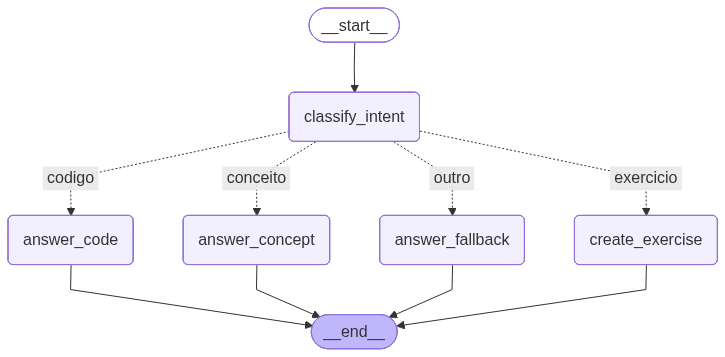

In [46]:
display_graph(router_graph)

## 7.6 Executando o roteador

Vamos testar três entradas diferentes.


In [48]:
result = router_graph.invoke({
    "pergunta": "Explique o que é MessagesState em LangGraph."
})

print("Intenção:", result["intencao"])
print("Justificativa:", result["justificativa"])
print("\nResposta:\n")
print(result["resposta"])


Intenção: conceito

Justificativa: O usuário está pedindo uma explicação sobre o que é MessagesState, o que se encaixa na categoria de 
conceito.

Resposta:

`MessagesState` em LangGraph é uma estrutura que gerencia o estado das mensagens em um fluxo de conversação. Ele é 
utilizado para armazenar e manipular as mensagens trocadas entre o usuário e o modelo, permitindo que o sistema 
mantenha um histórico das interações.

Aqui estão alguns pontos-chave sobre `MessagesState`:

1. **Armazenamento de Mensagens**: Ele mantém um registro das mensagens enviadas e recebidas, o que é essencial 
para contextos de conversação onde o histórico é relevante para a continuidade do diálogo.

2. **Manipulação de Estado**: Permite adicionar, remover ou modificar mensagens no estado, facilitando a gestão do 
fluxo de conversação.

3. **Integração com Outros Componentes**: `MessagesState` pode ser integrado com outros componentes do LangGraph, 
como agentes e ferramentas, para fornecer um contexto mais rico e dinâmico nas interações.

4. **Persistência de Contexto**: Ao manter o estado das mensagens, ele ajuda a preservar o contexto entre as 
interações, o que é crucial para a compreensão e resposta adequada do modelo.

Em resumo, `MessagesState` é uma parte fundamental da arquitetura de LangGraph, permitindo que as aplicações 
gerenciem conversas de forma eficaz e mantenham um histórico que enriquece a experiência do usuário.

In [49]:
result = router_graph.invoke({
    "pergunta": "Crie um exemplo pequeno de StateGraph com dois nós."
})

print("Intenção:", result["intencao"])
print("Justificativa:", result["justificativa"])
print("\nResposta:\n")
print(result["resposta"])


Intenção: codigo

Justificativa: O usuário está pedindo um exemplo de implementação, que se encaixa na categoria de código.

Resposta:

Claro! Aqui está um exemplo simples de um `StateGraph` com dois nós. Neste exemplo, vamos criar um gráfico de 
estados que representa um processo de "ligar" e "desligar" uma luz.

```langgraph
# Definindo os estados
state ON {
    # Ação ao entrar no estado ON
    onEnter {
        print("A luz está ligada.")
    }
}

state OFF {
    # Ação ao entrar no estado OFF
    onEnter {
        print("A luz está desligada.")
    }
}

# Definindo as transições entre os estados
transition OFF -> ON {
    # Ação ao fazer a transição de OFF para ON
    onTransition {
        print("Ligando a luz...")
    }
}

transition ON -> OFF {
    # Ação ao fazer a transição de ON para OFF
    onTransition {
        print("Desligando a luz...")
    }
}

# Inicializando o estado inicial
initialState OFF
```

### Explicação:
- Temos dois estados: `ON` e `OFF`.
- Cada estado possui uma ação que é executada quando o estado é ativado (`onEnter`).
- As transições entre os estados são definidas, com ações que ocorrem durante a transição (`onTransition`).
- O estado inicial do gráfico é `OFF`.

Esse exemplo ilustra como criar um `StateGraph` básico com dois estados e suas transições.

In [ ]:
result = router_graph.invoke({
    "pergunta": "Monte um exercício sobre reducers em LangGraph."
})

print("Intenção:", result["intencao"])
print("Justificativa:", result["justificativa"])
print("\nResposta:\n")
print(result["resposta"])


## Discussão

Esse exemplo apresenta um padrão comum em aplicações com LLM:

```text
classificar → rotear → executar especialista
```

Isso tende a ser melhor do que um único prompt gigante, porque:

- cada nó tem uma responsabilidade clara;
- cada prompt é mais específico;
- o fluxo fica observável;
- é mais fácil testar partes isoladas;
- novas rotas podem ser adicionadas sem reescrever tudo.


---

# 6. Ciclo com LLM: gerar → avaliar → revisar

Agora vamos construir um ciclo simples.

O objetivo é mostrar que um fluxo com LLM não precisa terminar na primeira resposta.

Fluxo:

```text
START
  ↓
generate_answer
  ↓
evaluate_answer
  ├── boa → END
  └── revisar → revise_answer → evaluate_answer
```

Esse é um exemplo de agente simples sem ferramentas.

Ele:

1. gera uma resposta;
2. avalia a resposta;
3. revisa se necessário;
4. para quando a resposta estiver boa ou quando atingir o limite de tentativas.


## 8.1 Estado do ciclo de revisão

Usaremos `total=False` para permitir que alguns campos sejam preenchidos ao longo da execução.

No `TypedDict`, o parâmetro `total=False` indica que todos os campos são opcionais por padrão.

Ou seja, o estado não precisa conter todas as chaves definidas na classe.


In [51]:
class ReviewState(TypedDict, total=False):
    pergunta: str
    resposta: str
    avaliacao: Literal["boa", "revisar"]
    feedback: str
    tentativas: int


## 8.2 Saída estruturada para avaliação

Mais uma vez, vamos evitar parsing manual de texto.

O avaliador retorna:

- `avaliacao`: `"boa"` ou `"revisar"`;
- `feedback`: motivo curto.


In [52]:
class AnswerEvaluation(BaseModel):
    avaliacao: Literal["boa", "revisar"] = Field(
        description="Indica se a resposta está boa ou se precisa de revisão."
    )
    feedback: str = Field(
        description="Feedback curto e acionável para melhorar a resposta."
    )


answer_evaluator = llm.with_structured_output(AnswerEvaluation)


## 8.3 Nó de geração inicial


In [53]:
def generate_answer(state: ReviewState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um tutor técnico de LangGraph.
Responda de forma objetiva, didática e útil para alguém que já conhece LangChain.
"""),
        HumanMessage(content=state["pergunta"]),
    ])

    return {
        "resposta": response.content,
        "tentativas": 1,
    }


## 8.4 Nó avaliador


In [54]:
def evaluate_answer(state: ReviewState):
    messages = [
        SystemMessage(content="""
Avalie a resposta abaixo para uma aula introdutória de LangGraph com LLMs.

Critérios:
- clareza;
- correção técnica;
- objetividade;
- utilidade para aluno que já conhece LangChain;
- foco em LangGraph como orquestração.

Se a resposta estiver adequada, marque como boa.
Se estiver genérica, longa demais, incompleta ou pouco prática, marque como revisar.
"""),
        HumanMessage(content=f"""
Pergunta:
{state["pergunta"]}

Resposta:
{state["resposta"]}
"""),
    ]

    evaluation = answer_evaluator.invoke(messages)

    return {
        "avaliacao": evaluation.avaliacao,
        "feedback": evaluation.feedback,
    }


## 8.5 Nó de revisão


In [55]:
def revise_answer(state: ReviewState):
    response = llm.invoke([
        SystemMessage(content="""
Você é um tutor técnico de LangGraph.
Revise a resposta com base no feedback.
Mantenha a resposta objetiva, correta e prática.
"""),
        HumanMessage(content=f"""
Pergunta:
{state["pergunta"]}

Resposta atual:
{state["resposta"]}

Feedback:
{state["feedback"]}

Produza uma versão melhor.
"""),
    ])

    return {
        "resposta": response.content,
        "tentativas": state["tentativas"] + 1,
    }


## 8.6 Função de decisão

Todo ciclo precisa de critério de parada.

Aqui vamos parar quando:

- a avaliação for `boa`; ou
- o número de tentativas chegar a 3.


In [56]:
def should_continue(state: ReviewState):
    if state["avaliacao"] == "boa":
        return "fim"

    if state["tentativas"] >= 3:
        return "fim"

    return "revisar"


## 8.7 Construindo o grafo com ciclo


In [57]:
builder = StateGraph(ReviewState)

builder.add_node("generate_answer", generate_answer)
builder.add_node("evaluate_answer", evaluate_answer)
builder.add_node("revise_answer", revise_answer)

builder.add_edge(START, "generate_answer")
builder.add_edge("generate_answer", "evaluate_answer")

builder.add_conditional_edges(
    "evaluate_answer",
    should_continue,
    {
        "revisar": "revise_answer",
        "fim": END,
    },
)

builder.add_edge("revise_answer", "evaluate_answer")

review_graph = builder.compile()


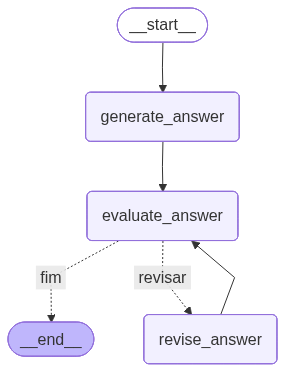

In [58]:
display_graph(review_graph)


## 8.8 Executando o ciclo


In [59]:
result = review_graph.invoke({
    "pergunta": "Explique por que LangGraph usa estado compartilhado."
})

print("Avaliação:", result["avaliacao"])
print("Tentativas:", result["tentativas"])
print("Feedback:", result["feedback"])
print("\nResposta final:\n")
print(result["resposta"])


Avaliação: boa

Tentativas: 1

Feedback: A resposta é clara, técnica e objetiva, abordando de forma útil o conceito de estado compartilhado em 
LangGraph, especialmente para quem já conhece LangChain.

Resposta final:

LangGraph utiliza estado compartilhado para facilitar a comunicação e a colaboração entre diferentes componentes e 
módulos dentro de uma aplicação. Aqui estão algumas razões principais para essa abordagem:

1. **Consistência de Dados**: O estado compartilhado garante que todos os componentes acessem a mesma versão dos 
dados, evitando inconsistências que podem ocorrer quando diferentes partes da aplicação mantêm seus próprios 
estados.

2. **Eficiência**: Ao centralizar o estado, LangGraph reduz a necessidade de passar dados entre componentes 
repetidamente, o que pode melhorar a eficiência e o desempenho da aplicação.

3. **Facilidade de Manutenção**: Com um estado compartilhado, é mais fácil rastrear e gerenciar mudanças, pois 
todas as atualizações são feitas em um único local. Isso simplifica a depuração e a manutenção do código.

4. **Colaboração**: Em aplicações que envolvem múltiplos agentes ou módulos, o estado compartilhado permite que 
esses componentes colaborem de maneira mais eficaz, pois eles podem reagir a mudanças no estado em tempo real.

5. **Escalabilidade**: Um estado compartilhado bem projetado pode ser escalável, permitindo que novos componentes 
sejam adicionados sem a necessidade de reestruturar a lógica de estado existente.

Esses fatores tornam o estado compartilhado uma escolha prática e eficiente para o desenvolvimento de aplicações 
complexas com LangGraph.

## Discussão

Esse exemplo mostra que um agente não precisa necessariamente usar ferramentas externas.

Um agente simples pode ser apenas um grafo que:

```text
gera → avalia → revisa → decide parar
```

A parte importante é que o controle não fica escondido dentro de um único prompt.

O controle está no grafo:

- nós especializados;
- estado explícito;
- arestas condicionais;
- critério de parada;
- streaming para observabilidade.


# 7. Exercícios de fixação

---
## Exercício 1 — Nova intenção

Adicione uma nova intenção chamada `comparacao`.

Depois:

1. atualize o schema `RouterState`;
2. atualize o modelo `IntentClassification`;
3. crie um nó chamado `answer_comparison`;
4. atualize `add_conditional_edges`;
5. teste com a pergunta:

```text
Compare LangChain e LangGraph.
```



---

## Exercício 2 — Classificador mais rígido

Modifique o classificador para retornar também um campo `confianca`, com valores:

```text
alta
media
baixa
```

Depois, crie uma regra:

- se a confiança for `baixa`, encaminhe para `answer_fallback`.

---

## Exercício 3 — Prompt especializado

Modifique o nó `answer_code` para sempre retornar:

1. explicação curta;
2. código;
3. observação sobre o papel do estado;
4. um pequeno desafio para o aluno.

---

## Exercício 4 — Ciclo com menos tentativas

Altere o ciclo de revisão para parar com no máximo 2 tentativas.

---

## Exercício 5 — Histórico de avaliações

Adicione ao `ReviewState` um campo chamado `historico_feedback`.

Dica: use um reducer para acumular os feedbacks.

---

## Exercício 6 — Comparar caminhos

Use `stream_mode="updates"` para comparar o caminho percorrido por estas três perguntas:

```text
Explique MessagesState.
Crie um exemplo de código com StateGraph.
Monte um exercício sobre add_messages.
```

Observe qual nó especializado foi chamado em cada caso.


---

# 8. Resumo da aula

Neste notebook, vimos como usar LLMs dentro de LangGraph sem transformar o grafo em uma caixa-preta.

A ideia central foi separar dois papéis:

- o LLM executa tarefas como responder, classificar, avaliar ou revisar;
- o grafo organiza o fluxo, o estado, as decisões e os ciclos da aplicação.

Aprendemos a:

- usar `MessagesState` para criar um chatbot simples;
- declarar `messages` explicitamente com `add_messages`;
- adicionar prompt de sistema dentro de um nó;
- observar atualizações com `stream_mode="updates"`;
- usar um LLM como classificador de intenção;
- rotear o fluxo com `add_conditional_edges`;
- criar nós especializados por tipo de solicitação;
- criar um ciclo de geração, avaliação e revisão.

| Conceito | Ideia principal |
|---|---|
| `MessagesState` | Estado especializado para aplicações baseadas em mensagens |
| `messages` | Histórico conversacional usado como estado do grafo |
| `add_messages` | Reducer usado para acumular mensagens corretamente |
| Prompt de sistema | Instrução usada para controlar o comportamento do LLM dentro de um nó |
| `stream` | Forma de observar a execução do grafo passo a passo |
| Classificação de intenção | Uso do LLM para decidir qual caminho o fluxo deve seguir |
| Nó especializado | Nó responsável por tratar um tipo específico de solicitação |
| Roteamento condicional | Decisão do próximo nó com base no estado |
| Ciclo de revisão | Fluxo em que o LLM gera, avalia e melhora uma resposta |

A ideia principal da aula foi:

> LangChain fornece componentes para trabalhar com modelos.  
> LangGraph organiza esses componentes em fluxos com estado, decisão e controle.

---

## 10. Checklist de entendimento

Antes de seguir para agentes com ferramentas, você deve conseguir responder:

1. Por que `messages` é um estado natural para aplicações conversacionais?
2. Para que serve o reducer `add_messages`?
3. Qual é a diferença entre chamar um LLM diretamente e chamar um LLM dentro de um nó do grafo?
4. Como um prompt de sistema pode alterar o comportamento de um nó?
5. Como `stream` ajuda a observar a execução do grafo?
6. Como um LLM pode ser usado como classificador de intenção?
7. Como `add_conditional_edges` permite rotear o fluxo?
8. Por que pode ser útil criar nós especializados por intenção?
9. O que caracteriza um ciclo de geração, avaliação e revisão?
10. Por que o grafo continua sendo importante mesmo quando várias etapas usam LLMs?

---

## 11. Próximos passos

Este notebook ainda não usa ferramentas externas.

O próximo passo natural é construir um grafo em que o LLM não apenas gera texto, mas também decide quando executar ações por meio de ferramentas.

A próxima aula pode avançar para:

```text
LangGraph com ferramentas: de workflow com LLM para agente com ações

---

# Referências

- LangGraph — Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- LangGraph — Streaming: https://docs.langchain.com/oss/python/langgraph/streaming
- LangGraph — Referência de StateGraph: https://reference.langchain.com/python/langgraph/graph/state/StateGraph
- LangGraph — `add_messages`: https://reference.langchain.com/python/langgraph/graph/message/add_messages
